# Analyse BCA – Biomek 4000 (fichier bca_absorbance_3.csv)

Ce notebook analyse les données d'absorbance issues d'un dosage BCA réalisé sur un robot Biomek 4000.

**Principe du test BCA :**  
En milieu alcalin, les protéines réduisent le Cu²⁺ en Cu⁺. L'ion Cu⁺ forme ensuite un complexe violet avec l'acide bicinchoninique (BCA), absorbant à 562 nm (mesuré ici à 595 nm).  
L'absorbance est proportionnelle à la concentration en protéines.

**Structure du fichier :**
- Chaque standard BSA est une entrée `Experiment` séparée : `Triplicate 1_1` à `Triplicate 1_9` + `Blank 1`
- 3 groupes de triplicats expérimentaux (Triplicate 1, 2, 3)
- 3 lectures techniques (`Read = 1, 2, 3`) par entrée

**Ordre des opérations :**
1. Soustraire le blanc du même groupe et de la même lecture technique (Read)
2. Faire la moyenne des 3 lectures techniques
3. Statistiques par concentration BSA
4. Régression linéaire et courbe de calibration
5. Calculer les concentrations de Prot X

## Section 2 : Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print('Bibliothèques importées avec succès.')

Bibliothèques importées avec succès.


## Section 3 : Importation des données

Le fichier CSV utilise le séparateur `;` et contient 4 colonnes : `Read`, `Experiment`, `Absorbance`, `Well`.

In [2]:
df = pd.read_csv('bca_absorbance_3.csv', sep=';')

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Lectures techniques : {sorted(df["Read"].unique())}')
print(f'Expériences uniques : {df["Experiment"].nunique()}')
print()
print('Aperçu des données :')
df.head(12)

Dimensions : 102 lignes × 4 colonnes
Lectures techniques : [np.int64(1), np.int64(2), np.int64(3)]
Expériences uniques : 34

Aperçu des données :


,Read,Experiment,Absorbance,Well
0,1,Triplicate 1_1,0.977,1
1,1,Triplicate 1_2,0.772,13
2,1,Triplicate 1_3,0.571,25
3,1,Triplicate 1_4,0.607,37
4,1,Triplicate 1_5,0.397,49
5,1,Triplicate 1_6,0.346,61
6,1,Triplicate 1_7,0.313,73
7,1,Triplicate 1_8,0.257,85
8,1,Triplicate 1_9,0.239,2
9,1,Blank 1,0.108,14


## Section 4 : Conversion des numéros de puits en identifiants

Le robot numérote les puits de 1 à 96 (colonne par colonne).  
On convertit en identifiants classiques : A1, B3, etc.

**Formule de conversion :**
- Ligne (lettre) = `(numéro - 1) // 12` → index dans A–H
- Colonne (chiffre) = `(numéro - 1) % 12 + 1`

In [3]:
lignes = list('ABCDEFGH')

def numero_vers_id(n):
    lettre = lignes[(n - 1) // 12]
    colonne = (n - 1) % 12 + 1
    return f'{lettre}{colonne}'

df['Well_ID'] = df['Well'].apply(numero_vers_id)
df['Row']    = df['Well_ID'].str[0]
df['Column'] = df['Well_ID'].str[1:].astype(int)

print('Exemples de conversion :')
df[['Well', 'Well_ID', 'Row', 'Column']].drop_duplicates().head(10)

Exemples de conversion :


,Well,Well_ID,Row,Column
0,1,A1,A,1
1,13,B1,B,1
2,25,C1,C,1
3,37,D1,D,1
4,49,E1,E,1
5,61,F1,F,1
6,73,G1,G,1
7,85,H1,H,1
8,2,A2,A,2
9,14,B2,B,2


## Section 5 : Identification des standards, blancs et inconnus

On classe chaque entrée selon son type :
- **BSA_standard** : `Triplicate X_Y` (standards de concentration connue)
- **Blanc** : `Blank X` (absence de protéine)
- **Inconnu** : `Prot X_*` (échantillons à doser)

On extrait aussi le numéro de groupe (1, 2 ou 3) pour pouvoir associer chaque standard à son blanc correspondant.

In [4]:
# Concentrations BSA : suffixe _1=1.0, _2=0.9, ..., _9=0.2 mg/mL ; Blank=0.0
CONCENTRATIONS_SUFFIXE = {
    '1': 1.0, '2': 0.9, '3': 0.8, '4': 0.7, '5': 0.6,
    '6': 0.5, '7': 0.4, '8': 0.3, '9': 0.2
}

# Facteurs de dilution des inconnus
FACTEURS_DILUTION = {
    'Prot X_stock': 1,
    'Prot X_d2':    2,
    'Prot X_d5':    5,
    'Prot X_d10':  10
}

def get_sample_type(exp):
    if exp.startswith('Triplicate'):
        return 'BSA_standard'
    elif exp.startswith('Blank'):
        return 'Blanc'
    else:
        return 'Inconnu'

def get_group(exp):
    if exp.startswith('Triplicate'):
        return int(exp.split(' ')[1].split('_')[0])
    elif exp.startswith('Blank'):
        return int(exp.split(' ')[1])
    else:
        return None

def get_bsa_conc(exp):
    if exp.startswith('Triplicate'):
        suffixe = exp.split('_')[1]
        return CONCENTRATIONS_SUFFIXE.get(suffixe, np.nan)
    elif exp.startswith('Blank'):
        return 0.0
    else:
        return np.nan

df['Sample_Type']           = df['Experiment'].apply(get_sample_type)
df['Groupe']                = df['Experiment'].apply(get_group)
df['BSA_concentration_mg_mL'] = df['Experiment'].apply(get_bsa_conc)
df['Facteur_dilution']      = df['Experiment'].map(FACTEURS_DILUTION).fillna(1.0)

print('Répartition par type :')
print(df[['Experiment', 'Sample_Type', 'Groupe', 'BSA_concentration_mg_mL']]
      .drop_duplicates()
      .sort_values(['Sample_Type', 'Groupe', 'BSA_concentration_mg_mL'], ascending=[True, True, False])
      .to_string(index=False))

Répartition par type :
    Experiment  Sample_Type  Groupe  BSA_concentration_mg_mL
Triplicate 1_1 BSA_standard     1.0                      1.0
Triplicate 1_2 BSA_standard     1.0                      0.9
Triplicate 1_3 BSA_standard     1.0                      0.8
Triplicate 1_4 BSA_standard     1.0                      0.7
Triplicate 1_5 BSA_standard     1.0                      0.6
Triplicate 1_6 BSA_standard     1.0                      0.5
Triplicate 1_7 BSA_standard     1.0                      0.4
Triplicate 1_8 BSA_standard     1.0                      0.3
Triplicate 1_9 BSA_standard     1.0                      0.2
Triplicate 2_1 BSA_standard     2.0                      1.0
Triplicate 2_2 BSA_standard     2.0                      0.9
Triplicate 2_3 BSA_standard     2.0                      0.8
Triplicate 2_4 BSA_standard     2.0                      0.7
Triplicate 2_5 BSA_standard     2.0                      0.6
Triplicate 2_6 BSA_standard     2.0                      0.5
T

## Section 6 : Correction par le blanc

**Principe :**  
Le blanc représente l'absorbance du réactif seul (sans protéine).  
On soustrait le blanc de chaque mesure pour obtenir l'absorbance nette due aux protéines.

**Règle d'appariement :**
- Pour chaque standard BSA : utiliser le blanc du **même groupe** et de la **même lecture technique** (Read)
  - Exemple : `Triplicate 1_3, Read=2` → corrigé par `Blank 1, Read=2`
- Pour les inconnus (Prot X) : utiliser la **moyenne des 3 blancs** pour la même lecture technique

> **Pourquoi corriger avant de moyenner ?**  
> Si le blanc varie légèrement entre les lectures techniques, soustraire avant la moyenne > garantit que chaque mesure est corrigée par son blanc exact.

In [5]:
# Table de référence des blancs : (Groupe, Read) → Absorbance_blanc
blancs = df[df['Sample_Type'] == 'Blanc'].copy()
table_blancs = blancs.set_index(['Groupe', 'Read'])['Absorbance']

# Moyenne des blancs par Read (pour les inconnus)
blanc_moyen_par_read = blancs.groupby('Read')['Absorbance'].mean()

def corriger_absorbance(row):
    if row['Sample_Type'] == 'BSA_standard':
        blanc = table_blancs.get((row['Groupe'], row['Read']), np.nan)
        return row['Absorbance'] - blanc
    elif row['Sample_Type'] == 'Blanc':
        # Le blanc soustrait par lui-même = 0
        blanc = table_blancs.get((row['Groupe'], row['Read']), np.nan)
        return row['Absorbance'] - blanc
    else:  # Inconnu
        blanc = blanc_moyen_par_read.get(row['Read'], np.nan)
        return row['Absorbance'] - blanc

df['Abs_corrigee'] = df.apply(corriger_absorbance, axis=1)

print('Valeurs des blancs utilisées pour la correction :')
print(blancs[['Read', 'Experiment', 'Absorbance']].sort_values(['Read', 'Experiment']).to_string(index=False))
print()
print('Blanc moyen par lecture (pour Prot X) :')
for read, val in blanc_moyen_par_read.items():
    print(f'  Read {read} : {val:.4f}')
print()
print('Aperçu après correction (5 premières lignes BSA) :')
df[df['Sample_Type'] == 'BSA_standard'][['Read', 'Experiment', 'Absorbance', 'Abs_corrigee']].head(5)

Valeurs des blancs utilisées pour la correction :
 Read Experiment  Absorbance
    1    Blank 1       0.108
    1    Blank 2       0.107
    1    Blank 3       0.107
    2    Blank 1       0.108
    2    Blank 2       0.107
    2    Blank 3       0.108
    3    Blank 1       0.108
    3    Blank 2       0.107
    3    Blank 3       0.107

Blanc moyen par lecture (pour Prot X) :
  Read 1 : 0.1073
  Read 2 : 0.1077
  Read 3 : 0.1073

Aperçu après correction (5 premières lignes BSA) :


,Read,Experiment,Absorbance,Abs_corrigee
0,1,Triplicate 1_1,0.977,0.869
1,1,Triplicate 1_2,0.772,0.664
2,1,Triplicate 1_3,0.571,0.463
3,1,Triplicate 1_4,0.607,0.499
4,1,Triplicate 1_5,0.397,0.289


## Section 7 : Moyenne des lectures techniques

Chaque puits a été lu 3 fois par le lecteur de plaque (`Read = 1, 2, 3`).  
On calcule maintenant la moyenne de ces 3 lectures **sur les absorbances déjà corrigées**.  
Le résultat est un tableau `condition_summary` avec une ligne par condition expérimentale.

In [6]:
condition_summary = (
    df.groupby(['Experiment', 'Well_ID', 'Sample_Type', 'Groupe',
                'BSA_concentration_mg_mL', 'Facteur_dilution'],
               dropna=False)
    ['Abs_corrigee']
    .agg(
        Abs_corrigee_moyenne='mean',
        Abs_corrigee_ecart_type='std',
        N_lectures='count'
    )
    .reset_index()
)

print(f'condition_summary : {condition_summary.shape[0]} lignes')
print()
print('Standards BSA (triplicats) :')
condition_summary[condition_summary['Sample_Type'] == 'BSA_standard'][
    ['Experiment', 'Well_ID', 'Groupe', 'BSA_concentration_mg_mL',
     'Abs_corrigee_moyenne', 'Abs_corrigee_ecart_type']
].sort_values(['Groupe', 'BSA_concentration_mg_mL'], ascending=[True, False]).to_string(index=False)


condition_summary : 34 lignes

Standards BSA (triplicats) :


'    Experiment Well_ID  Groupe  BSA_concentration_mg_mL  Abs_corrigee_moyenne  Abs_corrigee_ecart_type\nTriplicate 1_1      A1     1.0                      1.0              0.877000                 0.008000\nTriplicate 1_2      B1     1.0                      0.9              0.665667                 0.002082\nTriplicate 1_3      C1     1.0                      0.8              0.463333                 0.002517\nTriplicate 1_4      D1     1.0                      0.7              0.498667                 0.001528\nTriplicate 1_5      E1     1.0                      0.6              0.285333                 0.003215\nTriplicate 1_6      F1     1.0                      0.5              0.234000                 0.003606\nTriplicate 1_7      G1     1.0                      0.4              0.208667                 0.004041\nTriplicate 1_8      H1     1.0                      0.3              0.142667                 0.006028\nTriplicate 1_9      A2     1.0                      0.2        

In [7]:
# Affichage tableau complet
condition_summary[condition_summary['Sample_Type'] == 'BSA_standard'][
    ['Experiment', 'Well_ID', 'Groupe', 'BSA_concentration_mg_mL',
     'Abs_corrigee_moyenne', 'Abs_corrigee_ecart_type']
].sort_values(['Groupe', 'BSA_concentration_mg_mL'], ascending=[True, False])

,Experiment,Well_ID,Groupe,BSA_concentration_mg_mL,Abs_corrigee_moyenne,Abs_corrigee_ecart_type
7,Triplicate 1_1,A1,1.0,1.0,0.877000,0.008000
8,Triplicate 1_2,B1,1.0,0.9,0.665667,0.002082
9,Triplicate 1_3,C1,1.0,0.8,0.463333,0.002517
10,Triplicate 1_4,D1,1.0,0.7,0.498667,0.001528
11,Triplicate 1_5,E1,1.0,0.6,0.285333,0.003215
12,Triplicate 1_6,F1,1.0,0.5,0.234000,0.003606
13,Triplicate 1_7,G1,1.0,0.4,0.208667,0.004041
14,Triplicate 1_8,H1,1.0,0.3,0.142667,0.006028
15,Triplicate 1_9,A2,1.0,0.2,0.126000,0.004359
16,Triplicate 2_1,C2,2.0,1.0,0.738333,0.001528


## Section 8 : Statistiques BSA par concentration

Les 3 groupes de triplicats (Triplicate 1, 2, 3) permettent d'estimer la variabilité entre réplicats expérimentaux pour chaque concentration BSA.  
On calcule la moyenne et l'écart-type sur les 3 valeurs (une par groupe) pour chaque concentration.

In [8]:
bsa_df = condition_summary[condition_summary['Sample_Type'] == 'BSA_standard'].copy()

bsa_stats = (
    bsa_df.groupby('BSA_concentration_mg_mL')['Abs_corrigee_moyenne']
    .agg(
        Abs_moyenne_triplicats='mean',
        Abs_ecart_type_triplicats='std',
        N_triplicats='count'
    )
    .reset_index()
    .sort_values('BSA_concentration_mg_mL', ascending=False)
)

# CV% pour évaluer la reproductibilité
bsa_stats['CV_pct'] = (bsa_stats['Abs_ecart_type_triplicats'] /
                        bsa_stats['Abs_moyenne_triplicats'] * 100).round(1)

print('Statistiques BSA par concentration (sur les 3 triplicats) :')
bsa_stats

Statistiques BSA par concentration (sur les 3 triplicats) :


,BSA_concentration_mg_mL,Abs_moyenne_triplicats,Abs_ecart_type_triplicats,N_triplicats,CV_pct
8,1.0,0.759333,0.108699,3,14.3
7,0.9,0.649000,0.018352,3,2.8
6,0.8,0.510222,0.040656,3,8.0
5,0.7,0.490000,0.017072,3,3.5
4,0.6,0.324444,0.044374,3,13.7
3,0.5,0.261000,0.026359,3,10.1
2,0.4,0.224556,0.016174,3,7.2
1,0.3,0.150778,0.010772,3,7.1
0,0.2,0.084222,0.039561,3,47.0


## Section 9 : Courbe de calibration et régression linéaire

On effectue une régression linéaire : **Absorbance = a × Concentration + b**

- `a` (slope) : pente – sensibilité du test
- `b` (intercept) : ordonnée à l'origine
- `R²` : qualité de l'ajustement (1 = parfait)

On utilise les **moyennes des 3 triplicats** (`bsa_stats`) pour la régression.

In [9]:
# Données pour la régression
x = bsa_stats['BSA_concentration_mg_mL'].values
y = bsa_stats['Abs_moyenne_triplicats'].values

# Régression linéaire
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2

print(f'Résultats de la régression linéaire :')
print(f'  Pente (a)       : {slope:.4f}')
print(f'  Ordonnée (b)    : {intercept:.4f}')
print(f'  R²              : {r_squared:.4f}')
print(f'  Équation        : A = {slope:.4f} × C + {intercept:.4f}')

Résultats de la régression linéaire :
  Pente (a)       : 0.8326
  Ordonnée (b)    : -0.1158
  R²              : 0.9749
  Équation        : A = 0.8326 × C + -0.1158


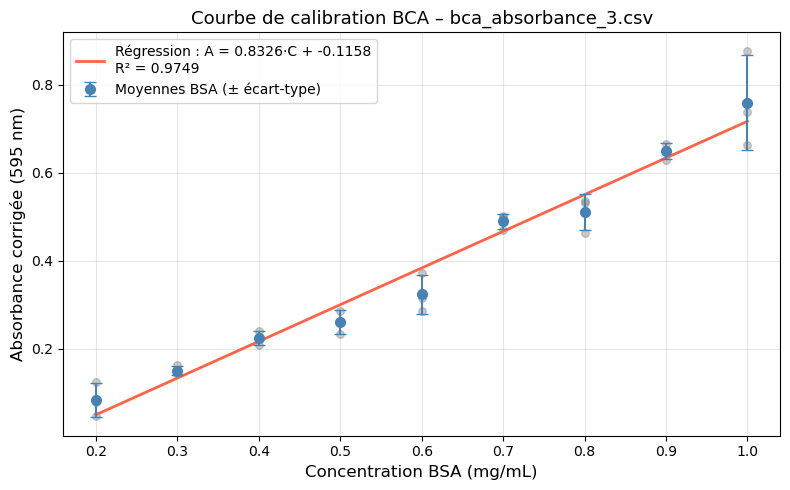

Figure sauvegardée : courbe_calibration_bca3.png


In [10]:
# Tracé de la courbe de calibration
fig, ax = plt.subplots(figsize=(8, 5))

# Points individuels des 3 triplicats (en gris, plus discrets)
for groupe in [1, 2, 3]:
    g = bsa_df[bsa_df['Groupe'] == groupe]
    ax.scatter(g['BSA_concentration_mg_mL'], g['Abs_corrigee_moyenne'],
               alpha=0.4, s=30, color='gray', zorder=2)

# Moyennes des triplicats
ax.errorbar(
    bsa_stats['BSA_concentration_mg_mL'],
    bsa_stats['Abs_moyenne_triplicats'],
    yerr=bsa_stats['Abs_ecart_type_triplicats'],
    fmt='o', color='steelblue', markersize=7, capsize=4,
    label='Moyennes BSA (± écart-type)', zorder=3
)

# Droite de régression
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='tomato', linewidth=2,
        label=f'Régression : A = {slope:.4f}·C + {intercept:.4f}\nR² = {r_squared:.4f}')

ax.set_xlabel('Concentration BSA (mg/mL)', fontsize=12)
ax.set_ylabel('Absorbance corrigée (595 nm)', fontsize=12)
ax.set_title('Courbe de calibration BCA – bca_absorbance_3.csv', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('courbe_calibration_bca3.png', dpi=150)
plt.show()
print('Figure sauvegardée : courbe_calibration_bca3.png')

## Section 10 : Analyse des résidus

Les résidus sont les écarts entre les valeurs mesurées et les valeurs prédites par le modèle.  
Un bon modèle linéaire produit des résidus aléatoires, répartis de façon symétrique autour de zéro.  
Un patron systématique indiquerait une non-linéarité.

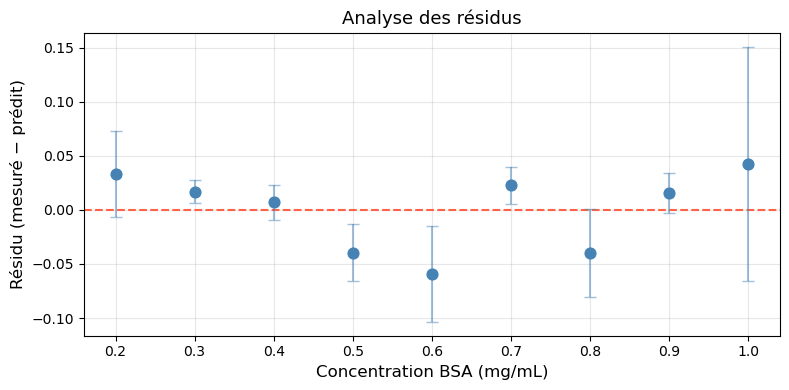

In [11]:
# Valeurs prédites et résidus
y_pred = slope * x + intercept
residus = y - y_pred

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, residus, color='steelblue', s=60, zorder=3)
ax.axhline(0, color='tomato', linewidth=1.5, linestyle='--')

# Barres d'erreur sur les résidus
ax.errorbar(x, residus,
            yerr=bsa_stats['Abs_ecart_type_triplicats'].values,
            fmt='none', color='steelblue', alpha=0.5, capsize=4)

ax.set_xlabel('Concentration BSA (mg/mL)', fontsize=12)
ax.set_ylabel('Résidu (mesuré − prédit)', fontsize=12)
ax.set_title('Analyse des résidus', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residus_bca3.png', dpi=150)
plt.show()

## Section 11 : Calcul des concentrations de Prot X

On inverse la droite de calibration pour obtenir la concentration :

$$C = \frac{A_{\text{corrigée}} - b}{a}$$

Pour les inconnus, la correction a utilisé le **blanc moyen** des 3 groupes (Blank 1, 2, 3) pour chaque lecture technique.  
On tient compte du **facteur de dilution** pour retrouver la concentration dans l'échantillon initial.

In [12]:
# Extraire les inconnus depuis condition_summary
prot_x = condition_summary[condition_summary['Sample_Type'] == 'Inconnu'].copy()

# Calculer la concentration à partir de l'absorbance corrigée
prot_x['Concentration_mesuree_mg_mL'] = (
    (prot_x['Abs_corrigee_moyenne'] - intercept) / slope
).round(4)

prot_x['Concentration_initiale_mg_mL'] = (
    prot_x['Concentration_mesuree_mg_mL'] * prot_x['Facteur_dilution']
).round(4)

# Tableau résultat
resultat_prot_x = prot_x[[
    'Experiment', 'Well_ID',
    'Abs_corrigee_moyenne', 'Abs_corrigee_ecart_type',
    'Facteur_dilution',
    'Concentration_mesuree_mg_mL',
    'Concentration_initiale_mg_mL'
]].reset_index(drop=True)

print('Concentrations de Prot X :')
resultat_prot_x

Concentrations de Prot X :


,Experiment,Well_ID,Abs_corrigee_moyenne,Abs_corrigee_ecart_type,Facteur_dilution,Concentration_mesuree_mg_mL,Concentration_initiale_mg_mL
0,Prot X_d10,D5,-0.003444,0.000192,10.0,0.1350,1.3500
1,Prot X_d2,B5,0.000556,0.000192,2.0,0.1398,0.2796
2,Prot X_d5,C5,-0.003444,0.000192,5.0,0.1350,0.6750
3,Prot X_stock,A5,0.083222,0.001503,1.0,0.2391,0.2391


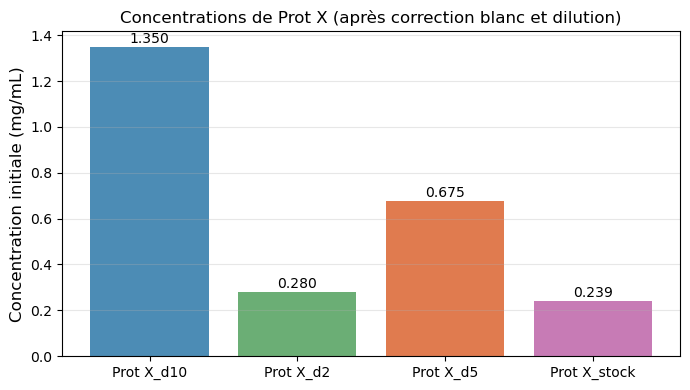

In [13]:
# Visualisation des concentrations initiales
fig, ax = plt.subplots(figsize=(7, 4))

noms = resultat_prot_x['Experiment'].tolist()
concs = resultat_prot_x['Concentration_initiale_mg_mL'].tolist()

barres = ax.bar(noms, concs, color=['#4C8CB5', '#6BAE75', '#E07B4F', '#C77BB5'])

for barre, val in zip(barres, concs):
    ax.text(barre.get_x() + barre.get_width() / 2,
            barre.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Concentration initiale (mg/mL)', fontsize=12)
ax.set_title('Concentrations de Prot X (après correction blanc et dilution)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('concentrations_protX_bca3.png', dpi=150)
plt.show()

## Section 12 : Export des résultats

On exporte 3 fichiers CSV :
- `condition_summary_bca3.csv` : absorbances corrigées moyennées pour toutes les conditions
- `bsa_stats_bca3.csv` : statistiques BSA par concentration (moyennes des 3 triplicats)
- `concentrations_protX_bca3.csv` : concentrations calculées pour Prot X

In [14]:
condition_summary.to_csv('condition_summary_bca3.csv', index=False, sep=';')
bsa_stats.to_csv('bsa_stats_bca3.csv', index=False, sep=';')
resultat_prot_x.to_csv('concentrations_protX_bca3.csv', index=False, sep=';')

print('Fichiers exportés :')
print('  - condition_summary_bca3.csv')
print('  - bsa_stats_bca3.csv')
print('  - concentrations_protX_bca3.csv')
print()
print('=== Résumé final ===')
print(f'Droite de calibration : A = {slope:.4f} × C + {intercept:.4f}')
print(f'R² = {r_squared:.4f}')
print()
print('Concentrations Prot X (stock reconstitué) :')
for _, row in resultat_prot_x.iterrows():
    print(f'  {row["Experiment"]:15s} → {row["Concentration_initiale_mg_mL"]:.4f} mg/mL')

Fichiers exportés :
  - condition_summary_bca3.csv
  - bsa_stats_bca3.csv
  - concentrations_protX_bca3.csv

=== Résumé final ===
Droite de calibration : A = 0.8326 × C + -0.1158
R² = 0.9749

Concentrations Prot X (stock reconstitué) :
  Prot X_d10      → 1.3500 mg/mL
  Prot X_d2       → 0.2796 mg/mL
  Prot X_d5       → 0.6750 mg/mL
  Prot X_stock    → 0.2391 mg/mL
